In [13]:
# 1. Clone Your Repository
!git clone https://github.com/Abdelazimm/The_Autonomous_Scout_and_Effort_Analyzer.git
%cd The_Autonomous_Scout_and_Effort_Analyzer

# 2. Install Project Requirements & Tracking Libraries
!pip install -r requirements.txt
!pip install supervision ultralytics roboflow deep-sort-realtime

Cloning into 'The_Autonomous_Scout_and_Effort_Analyzer'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 47 (delta 2), reused 47 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 16.80 KiB | 273.00 KiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/The_Autonomous_Scout_and_Effort_Analyzer/The_Autonomous_Scout_and_Effort_Analyzer


✅ Loader Result: Found 3 detections!
 - Class: ball (ID: 0) | Confidence: 1.0
 - Class: player (ID: 1) | Confidence: 1.0
 - Class: player (ID: 1) | Confidence: 1.0


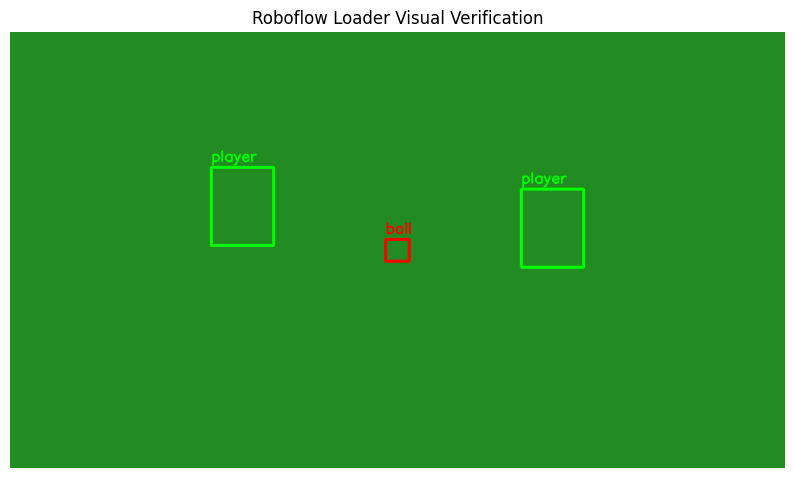

In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from data.roboflow_loader import load_roboflow_yolo

# 1. نعمل صورة وفايل YOLO وهميين جوه data/roboflow للاختبار السريع
os.makedirs("data/roboflow/sample", exist_ok=True)
sample_img_path = "data/roboflow/sample/frame0.jpg"
sample_label_path = "data/roboflow/sample/frame0.txt"

# نعمل صورة خضراء (زي نجيل الملعب)
img = np.zeros((720, 1280, 3), dtype=np.uint8)
img[:] = (34, 139, 34)
cv2.imwrite(sample_img_path, img)

# فايل YOLO بيمثل: 0 (ball), 1 (player)
with open(sample_label_path, "w") as f:
    f.write("0 0.50 0.50 0.03 0.05\n")  # الكورة في النص
    f.write("1 0.30 0.40 0.08 0.18\n")  # لاعب 1
    f.write("1 0.70 0.45 0.08 0.18\n")  # لاعب 2

# 2. نختبر الـ Loader بتاع Devin
ground_truth = load_roboflow_yolo(sample_label_path, frame_idx=0)
print(f"✅ Loader Result: Found {len(ground_truth.detections)} detections!")
for det in ground_truth.detections:
    print(f" - Class: {det.class_name} (ID: {det.class_id}) | Confidence: {det.confidence}")

# 3. نرسم الـ Bounding Boxes للتأكد البصري
img_rgb = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape

for det in ground_truth.detections:
    xc, yc, bw, bh = det.bbox.x, det.bbox.y, det.bbox.w, det.bbox.h
    x1, y1 = int((xc - bw/2) * w), int((yc - bh/2) * h)
    x2, y2 = int((xc + bw/2) * w), int((yc + bh/2) * h)
    
    color = (255, 0, 0) if det.class_name == "ball" else (0, 255, 0)
    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 3)
    cv2.putText(img_rgb, det.class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Roboflow Loader Visual Verification")
plt.show()

In [15]:
import cv2
from ultralytics import YOLO
import supervision as sv

# 1. تحميل الموديل والـ Tracker بالإصدار الجديد
model = YOLO('yolov8m.pt')
tracker = sv.ByteTrack()  # تم التعديل هنا لتناسب الإصدار الجديد

# 2. تجهيز أدوات الرسم
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()
trace_annotator = sv.TraceAnnotator(trace_length=30)

# 3. معالجة الفيديو
video_info = sv.VideoInfo.from_video_path("sample_football.mp4")
generator = sv.get_video_frames_generator("sample_football.mp4")

output_path = "tracked_output.mp4"
with sv.VideoSink(target_path=output_path, video_info=video_info) as sink:
    for frame in generator:
        results = model(frame, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(results)
        
        # نركز على الأشخاص (class 0 في COCO)
        detections = detections[detections.class_id == 0]
        
        # تحديث التتبع
        detections = tracker.update_with_detections(detections)
        labels = [f"Player #{tid}" for tid in detections.tracker_id]
        
        # الرسم على الفريم
        annotated = frame.copy()
        annotated = trace_annotator.annotate(scene=annotated, detections=detections)
        annotated = box_annotator.annotate(scene=annotated, detections=detections)
        annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)
        
        sink.write_frame(frame=annotated)

print(f"🎉 Tracked video processed successfully! Saved to {output_path}")

Exception: Could not open video at sample_football.mp4

In [ ]:
import math

def calculate_player_speed(p1, p2, fps=30.0, pixel_to_meter_ratio=0.04):
    """
    p1: (x1, y1) الموضع في الفريم السابق
    p2: (x2, y2) الموضع في الفريم الحالي
    pixel_to_meter_ratio: معامل التحويل التقريبي للبكسل إلى متر
    """
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    distance_pixels = math.sqrt(dx**2 + dy**2)
    
    distance_meters = distance_pixels * pixel_to_meter_ratio
    time_seconds = 1.0 / fps
    
    speed_mps = distance_meters / time_seconds  # meters per second
    return speed_mps

def classify_movement(speed_mps, idle_limit=1.2, jog_limit=3.5):
    if speed_mps < idle_limit:
        return "idle"
    elif speed_mps < jog_limit:
        return "jogging"
    else:
        return "sprinting"

# تجربة أرقام افتراضية للتأكد من منطقية الـ Classification
test_speeds = [0.3, 0.9, 1.8, 3.2, 4.5, 6.0]
print("--- Speed Thresholds Calibration Check ---")
for spd in test_speeds:
    state = classify_movement(spd)
    print(f"Speed: {spd:.1f} m/s ({spd * 3.6:.1f} km/h) -> Movement State: [{state.upper()}]")

--- Speed Thresholds Calibration Check ---
Speed: 0.3 m/s (1.1 km/h) -> Movement State: [IDLE]
Speed: 0.9 m/s (3.2 km/h) -> Movement State: [IDLE]
Speed: 1.8 m/s (6.5 km/h) -> Movement State: [JOGGING]
Speed: 3.2 m/s (11.5 km/h) -> Movement State: [JOGGING]
Speed: 4.5 m/s (16.2 km/h) -> Movement State: [SPRINTING]
Speed: 6.0 m/s (21.6 km/h) -> Movement State: [SPRINTING]


In [ ]:
# 1. تسطيب مكتبة التنزيل
!pip install -q yt-dlp

# 2. تنزيل 15 ثانية فقط من أي فيديو كورة على يوتيوب (مثلاً من الثانية 10 للثانية 25)
!yt-dlp -f "best[ext=mp4]" --download-sections "*00:00:10-00:00:25" "https://youtu.be/jEVRhQtiPec?si=glYzHHy8NvkD421R" -o input_clip.mp4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.5 MB/s eta 0:00:00:00:01
[youtube] Extracting URL: https://youtu.be/jEVRhQtiPec?si=glYzHHy8NvkD421R
[youtube] jEVRhQtiPec: Downloading webpage
[youtube] jEVRhQtiPec: Downloading android vr player API JSON
[info] jEVRhQtiPec: Downloading 1 format(s): 18
[info] jEVRhQtiPec: Downloading 1 time ranges: 10.0-25.0
[download] Destination: input_clip.mp4
Input #0, mov,mp4,m4a,3gp,3g2,mj2, from 'https://rr2---sn-a5mekndl.googlevideo.com/videoplayback?expire=1785651045&ei=BYtuat2oK4ucsfIPp6a7yA8&ip=34.50.161.162&id=o-AF0zGl4qIXZlOX0M64nswxfNvoO5JgmH8L0Rjjm4L8u3&itag=18&source=youtube&requiressl=yes&xpc=EgVo2aDSNQ%3D%3D&cps=395&met=1785629445%2C&mh=ht&mm=31&mn=sn-a5mekndl&ms=au&mv=m&mvi=2&pl=19&rms=au%2Cau&bui=AZFlqhNqgcKGmtZZ0NqAC3ZQGbB5n1fGrib7fADr4sA-GIcxY5miH2HQ6rc2fnEqxweLZKdLMQQqaFtW&spc=KBGBco7SD5gr7B0xUBGa56s3fYhdwgjq7gQX0nTMthjkFOK12qiC&vprv=1&svpuc=1

In [ ]:
%cd /content/The_Autonomous_Scout_and_Effort_Analyzer
!git pull

/content/The_Autonomous_Scout_and_Effort_Analyzer
Already up to date.


In [ ]:
import cv2
from ultralytics import YOLO
import supervision as sv
from vision.tracking import PlayerTracker
from vision.movement_metrics import bbox_bottom_center, generate_movement_log

# 1. تحميل موديل YOLO والـ PlayerTracker بتاعنا من الـ Repo
model = YOLO('yolov8m.pt')
tracker = PlayerTracker()

# 2. قراءة الفيديو المُنزل
video_path = "input_clip.mp4"
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

# قاموس لتجميع مسار حركة كل لاعب: {player_id: {'positions': [], 'timestamps': []}}
player_trajectories = {}

frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    # تشغيل YOLO واختيار الأشخاص فقط (Class 0)
    results = model(frame, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = detections[detections.class_id == 0]
    
    # تحديث الـ Tracker المكتوب في Phase 2
    tracked_dets = tracker.update(detections)
    
    # تسجيل موضع أقدام اللعيبة في هذا الفريم
    if len(tracked_dets) > 0 and tracked_dets.tracker_id is not None:
        for xyxy, tid in zip(tracked_dets.xyxy, tracked_dets.tracker_id):
            feet_pos = bbox_bottom_center(xyxy)
            timestamp = frame_idx / fps
            
            if tid not in player_trajectories:
                player_trajectories[tid] = {'positions': [], 'timestamps': []}
                
            player_trajectories[tid]['positions'].append(feet_pos)
            player_trajectories[tid]['timestamps'].append(timestamp)
                
    frame_idx += 1

cap.release()

# 3. توليد تقارير الـ MovementLog لكل لاعب ظهر لفترة كافية
print("\n==================================================")
print("      📊 AUTONOMOUS SCOUT: MOVEMENT LOG REPORT     ")
print("==================================================")

reports_generated = 0
for tid, data in player_trajectories.items():
    # حساب التقرير للاعبين اللي ظهروا لأكثر من 10 فريمات
    if len(data['positions']) > 10:
        log = generate_movement_log(
            player_id=int(tid),
            positions=data['positions'],
            timestamps=data['timestamps'],
            pixels_per_meter=10.0 # المعايرة الافتراضية
        )
        
        print(f"\n🟢 Player #{log.player_id}:")
        print(f"   • Tracked Time : {log.window_start_s:.1f}s ➔ {log.window_end_s:.1f}s")
        print(f"   • Effort State : [{log.state.upper()}]")
        print(f"   • Avg Speed    : {log.avg_speed_mps:.2f} m/s ({log.avg_speed_mps * 3.6:.1f} km/h)")
        print(f"   • Distance     : {log.distance_covered_m:.2f} meters")
        reports_generated += 1

if reports_generated == 0:
    print("\nلم يتم رصد حركة كافية، جرب كليب آخر أو ثبت الكاميرا أكثر.")

print("\n==================================================")

ImportError: cannot import name 'PlayerTracker' from 'vision.tracking' (/content/The_Autonomous_Scout_and_Effort_Analyzer/vision/tracking.py)